-Graphics-   -Graphics-   -Graphics-   -Graphics-
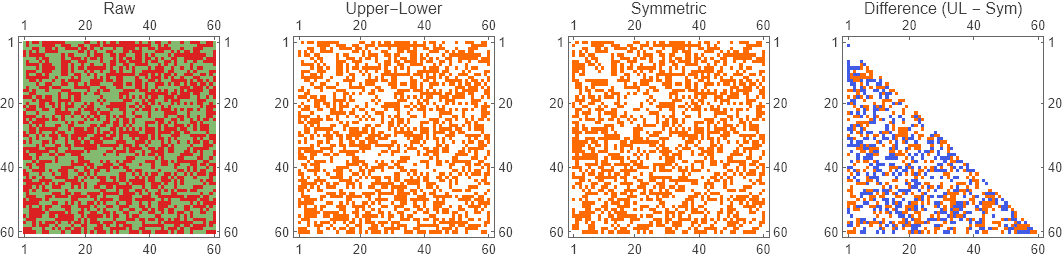

In [ ]:
g = ExampleData[{"NetworkGraph", "ZacharyKarateClub"}];

FindGraphCommunities[g];
(* CommunityGraphPlot[g, %] *)
(* CommunityGraphPlot[g, Method ->"Hierarchical"] *)

SeedRandom[]; 
rawAdj = RandomInteger[{0, 1}, {60, 60}];
rawPlot = MatrixPlot[rawAdj,
  PlotLabel -> "Raw",
  ColorFunction -> "Rainbow"
  ];
ulAdj = UpperTriangularize[rawAdj, 1] + LowerTriangularize[rawAdj, -1];
symAdj = UpperTriangularize[rawAdj, 1] + Transpose[UpperTriangularize[rawAdj, 1]];
ulPlot = MatrixPlot[ulAdj, 
  PlotLabel -> "Upper-Lower"
  ];
symPlot = MatrixPlot[symAdj,
  PlotLabel -> "Symmetric"
  ];
diffPlot = MatrixPlot[ulAdj - symAdj,
  PlotLabel -> "Difference (UL - Sym)"
  ];
Grid[{
  {rawPlot, ulPlot, symPlot, diffPlot}
}, Spacings -> {2, 2}]

Graph[<60>, <1320>]
Graph[<60>, <861>]
Graph[<60>, <459>]
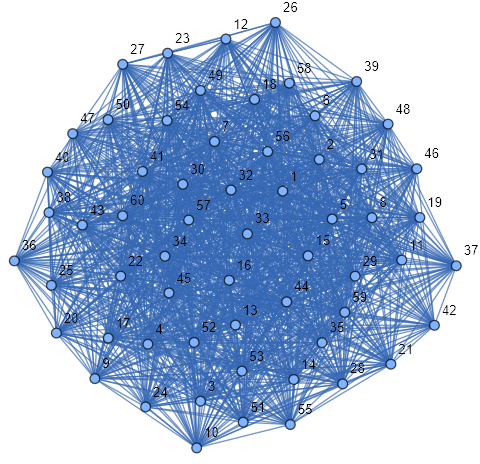
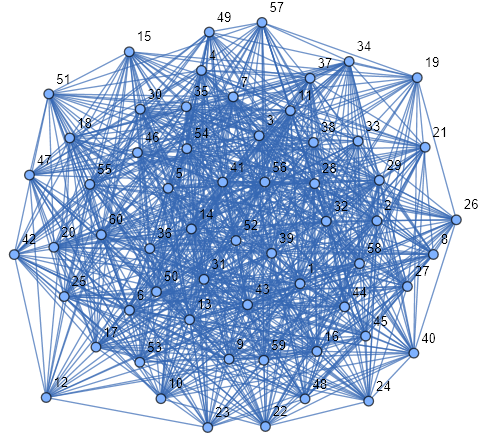
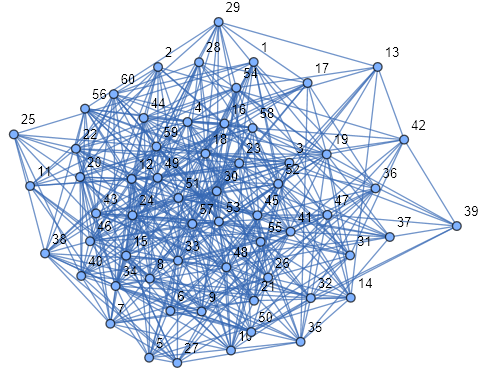

In [259]:
ulGraph = Graph[AdjacencyGraph[ulAdj,  VertexLabels -> "Name", DirectedEdges -> False]]
symGraph = Graph[AdjacencyGraph[symAdj,  VertexLabels -> "Name", DirectedEdges -> False]]
diffGraph = GraphDifference[ulGraph, symGraph, VertexLabels -> "Name"]

-Graphics-
-Graphics-
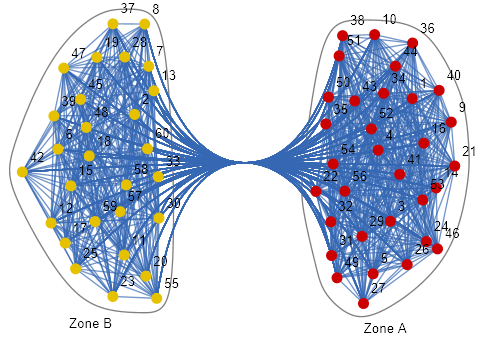
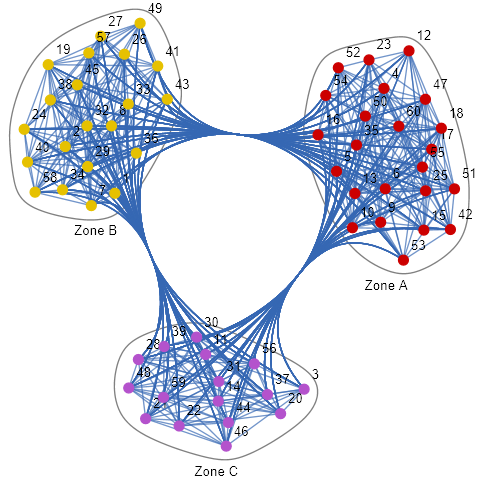

In [267]:
ulCommunities = FindGraphCommunities[ulGraph];
symCommunities = FindGraphCommunities[symGraph];
indexToLetters[i_] := Module[{n = i, s = ""}, 
    While[n > 0, s = FromCharacterCode[65 + Mod[n - 1, 26]] <> s; n = Quotient[n - 1, 26]]; s];
ulLabels = Table["Zone " <> indexToLetters[i], {i, Length[ulCommunities]}];
symLabels = Table["Zone " <> indexToLetters[i], {i, Length[symCommunities]}];
CommunityGraphPlot[ulGraph, CommunityLabels -> Placed[ulLabels, Below]]
CommunityGraphPlot[symGraph, CommunityLabels -> Placed[symLabels, Below]]

-Graphics-
-Graphics-
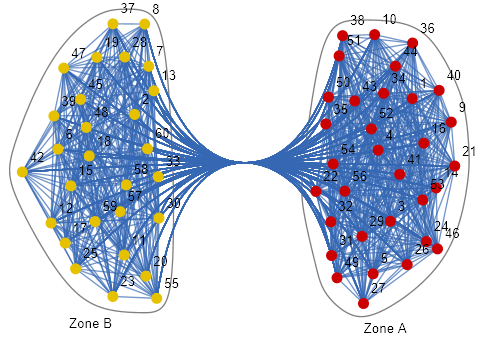
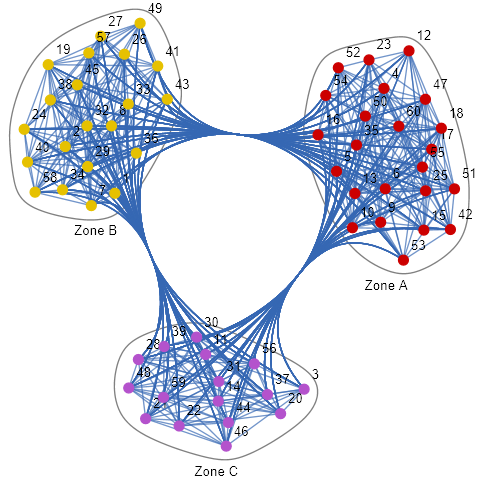

In [ ]:
CommunityGraphPlot[ulGraph, CommunityLabels -> Placed[ulLabels, Below]]
CommunityGraphPlot[symGraph, Method -> "SpringElectrical", CommunityLabels -> Placed[symLabels, Below]]